<a href="https://colab.research.google.com/github/ignaciomorenobarria21-a11y/Machine_Learning/blob/main/Sesion_09_Sobreoptimizacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎓 Fundamentos de Machine Learning

## Sesión 9: Sobreoptimización

**Máster en Formación Permanente en Inteligencia Artificial para el Sector Financiero**  
Universidad Internacional de Valencia · Edición Octubre 2025/26

---

📅 **Fecha:** 5 de febrero de 2026  
⏱️ **Duración:** ~100 minutos  
👨‍🏫 **Profesor:** Jaume Antolí Plaza

## 1. Introducción: ¿Qué es Sobreoptimizar?

En la sesión anterior aprendimos a separar datos **In-Sample** (entrenamiento) y **Out-of-Sample** (test). Pero hay un problema más sutil que la simple separación no resuelve.

```
DOS TIPOS DE OVERFITTING
═══════════════════════════════════════════════════════════════════════

    1. OVERFITTING DEL MODELO (ya lo conocemos)
    ──────────────────────────────────────────────
    
       El modelo memoriza los datos de entrenamiento.
       
       Síntoma:  Accuracy IS = 95%
                 Accuracy OOS = 52%
       
       Solución: Regularización, limitar profundidad, más datos...
    
    
    2. OVERFITTING DEL PROCESO (más peligroso)
    ──────────────────────────────────────────────
    
       NOSOTROS "memorizamos" qué configuración funciona mejor.
       
       Proceso típico:
       
           Probar configuración A → OOS = 51% → "No sirve"
           Probar configuración B → OOS = 49% → "No sirve"
           Probar configuración C → OOS = 53% → "No sirve"
           ...
           Probar configuración Z → OOS = 58% → "¡Esta es!"
       
       Problema: Hemos "contaminado" el OOS al usarlo para elegir.
                 El 58% ya no es una estimación honesta.
```

### El Problema de las Múltiples Comparaciones

```
SI PRUEBAS SUFICIENTES CONFIGURACIONES, ALGUNA "FUNCIONARÁ" POR AZAR
═══════════════════════════════════════════════════════════════════════

    Imagina que el mercado es COMPLETAMENTE ALEATORIO (50/50).
    
    Si pruebas 1 estrategia:
        → Probabilidad de >55% accuracy por azar: ~5%
    
    Si pruebas 100 estrategias:
        → Probabilidad de que ALGUNA tenga >55%: ~99%
    
    Si pruebas 1000 estrategias:
        → Encontrarás varias con >60% (¡por puro azar!)
    
    
    ANALOGÍA: MONOS LANZANDO DARDOS
    ─────────────────────────────────
    
       Si 1000 monos lanzan dardos a una diana,
       alguno acertará en el centro.
       
       ¿Significa que ese mono es un experto?
       
       No. Significa que probamos suficientes veces.
       
       
    En trading, si el "mono ganador" gestiona tu dinero...
    
        → Su siguiente lanzamiento será aleatorio.
        → Su "habilidad" desaparecerá.
```

## 2. Data Snooping en Trading

```
EL BACKTESTING: UNA MÁQUINA DE AUTOENGAÑO
═══════════════════════════════════════════════════════════════════════

    El proceso típico de un trader/quant:
    
    1. Tiene una idea: "RSI < 30 = comprar"
    2. Hace backtest → No funciona
    3. Ajusta: "RSI < 25 con volumen alto"
    4. Hace backtest → Mejor, pero no suficiente
    5. Ajusta: "RSI < 25, volumen alto, solo martes"
    6. Hace backtest → ¡Funciona!
    7. Opera en real → Pierde dinero
    
    
    ¿Qué pasó?
    
    Cada "ajuste" era en realidad una BÚSQUEDA de patrones
    que funcionan EN ESE HISTÓRICO ESPECÍFICO.
    
    El trader no encontró una estrategia rentable.
    Encontró RUIDO que parecía señal.


DATA SNOOPING BIAS
═══════════════════════════════════════════════════════════════════════

    Definición: Usar los mismos datos repetidamente para
                desarrollar y validar una estrategia.
    
    Formas comunes:
    
    ❌ Ajustar parámetros hasta que el backtest "se vea bien"
    ❌ Probar muchos indicadores y quedarse con los que funcionan
    ❌ Excluir períodos "anómalos" que arruinan los resultados
    ❌ Usar el OOS para decidir si la estrategia es buena
    ❌ "Optimizar" fechas de entrada/salida
    
    
    El problema fundamental:
    
        Cualquier dataset tiene PATRONES ALEATORIOS.
        Si buscas suficiente, encontrarás "algo".
        Pero ese "algo" no existirá en datos futuros.
```

### Por Qué las Estrategias "Mueren"

```
CICLO DE VIDA DE UNA ESTRATEGIA SOBREOPTIMIZADA
═══════════════════════════════════════════════════════════════════════

    Rendimiento
        ↑
        │         Backtest
        │        ┌────────┐
        │       /│████████│
        │      / │████████│
    ────┼─────/──│████████│──────────────────────────
        │   /    │████████│    Trading Real
        │  /     │████████│   ┌─────────────────
        │ /      │████████│   │░░░░░░░░░░░░░░░░
        │/       │████████│   │░░░░░░░░░░░░░░░░
        └────────┴────────┴───┴─────────────────────→ Tiempo
                          │
                    Puesta en
                    producción
    
    
    █ = Rendimiento en backtest (optimista, falso)
    ░ = Rendimiento en real (la verdad)
    
    
    La estrategia no "dejó de funcionar".
    Nunca funcionó realmente.
    Solo parecía funcionar en datos pasados.
```

## 3. El Sesgo de Supervivencia

```
SESGO DE SUPERVIVENCIA EN FONDOS DE INVERSIÓN
═══════════════════════════════════════════════════════════════════════

    "El fondo XYZ ha batido al mercado 10 años seguidos"
    
    Lo que NO te cuentan:
    
        Año 0: Se crean 1000 fondos
        Año 1: 500 baten al mercado (por azar), 500 cierran
        Año 2: 250 baten al mercado, 250 cierran
        Año 3: 125 baten al mercado, 125 cierran
        ...
        Año 10: ~1 fondo ha "batido al mercado 10 años"
    
    Ese fondo aparece en las noticias.
    Los 999 que cerraron no existen en las estadísticas.
    
    
    IMPLICACIÓN:
    
        Si pruebas 1000 estrategias y seleccionas la mejor,
        estás haciendo lo mismo que la industria de fondos.
        
        Tu "mejor estrategia" es probablemente el superviviente
        de un proceso aleatorio, no un sistema robusto.


EN MACHINE LEARNING
═══════════════════════════════════════════════════════════════════════

    Lo mismo ocurre cuando:
    
    • Pruebas muchas combinaciones de hiperparámetros
    • Pruebas muchos conjuntos de features
    • Pruebas muchos modelos diferentes
    • Pruebas muchas ventanas temporales
    
    Y te quedas con "el mejor".
    
    Ese "mejor" puede ser simplemente el superviviente
    de un proceso de búsqueda en ruido.
```

## 4. El Monkey Test: Concepto

```
¿TU MODELO ES MEJOR QUE UN MONO LANZANDO DARDOS?
═══════════════════════════════════════════════════════════════════════

    La pregunta fundamental:
    
        Si genero 100 estrategias COMPLETAMENTE ALEATORIAS,
        ¿mi modelo supera a la MAYORÍA de ellas?
    
    
    Si la respuesta es NO → Tu modelo no tiene valor real.
                           Solo encontró patrones aleatorios.
    
    Si la respuesta es SÍ → Tu modelo PODRÍA tener valor.
                           (Pero aún necesita más validación)


IMPLEMENTACIÓN DEL MONKEY TEST
═══════════════════════════════════════════════════════════════════════

    1. Entrenar tu modelo real (Random Forest)
       → Genera señales: +1 (long) o -1 (short) cada día
    
    2. Generar N "monos" (estrategias aleatorias)
       → Cada mono genera señales aleatorias: +1 o -1 cada día
       → Misma cantidad de operaciones que tu modelo
    
    3. Calcular equity curve de cada uno
       → Tu modelo: equity_RF
       → Monos: equity_mono_1, equity_mono_2, ..., equity_mono_N
    
    4. Comparar
       → ¿En qué percentil está tu modelo vs los monos?
       → Si está en el percentil 95+, es prometedor
       → Si está en el percentil 50, no es mejor que el azar


VISUALIZACIÓN ESPERADA
═══════════════════════════════════════════════════════════════════════

    IN-SAMPLE (Train)                    OUT-OF-SAMPLE (Test)
    
    Equity                               Equity
    ↑                                    ↑
    │      ████ ← RF                     │   ░░░░░░░░░░░░
    │    ██░░░░░░░░                      │  ░░░░████░░░░░ ← RF perdido
    │  ██░░░░░░░░░░░                     │ ░░░░░░░░░░░░░░░   entre monos
    │ █░░░░░░░░░░░░░░                    │░░░░░░░░░░░░░░░░
    │█░░░░░░░░░░░░░░░░                   │░░░░░░░░░░░░░░░░░
    └──────────────────→ Tiempo          └──────────────────→ Tiempo
    
    █ = Estrategia Random Forest
    ░ = 100 monos aleatorios
    
    En IS: El RF destaca claramente (ha "aprendido" los datos)
    En OOS: El RF es un mono más (lo "aprendido" era ruido)
```

---

# PARTE PRÁCTICA: Monkey Test con Random Forest

---

## 5. Cargar Librerías y Datos

In [ ]:
# ============================================================
# IMPORTAR LIBRERÍAS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

# Scikit-learn
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score

# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Mostrar todas las columnas en pandas
pd.set_option('display.max_columns', None)

# Semilla para reproducibilidad
np.random.seed(42)

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


In [ ]:
# ============================================================
# CARGA DE DATOS
# Dataset preparado en la Sesión 1 con indicadores técnicos
# ============================================================

# Cargar el dataset directamente desde Google Drive
url = 'https://drive.google.com/uc?id=13vNdqTBl4xZurr1jbcoVHCy9PinJosiL'
df = pd.read_csv(url, index_col=0, parse_dates=True)

print(f"Dataset cargado: {len(df):,} filas")
print(f"Período: {df.index[0].strftime('%Y-%m-%d')} a {df.index[-1].strftime('%Y-%m-%d')}")
print(f"Columnas totales: {len(df.columns)}")
df.head()

Dataset cargado: 2,489 filas
Período: 2010-05-25 a 2019-12-30
Columnas totales: 501


,Open,High,Low,Close,RSI_2,STOCH_2,WILLR_2,CCI_2,ADX_2,RSI_3,STOCH_3,WILLR_3,CCI_3,ADX_3,RSI_4,STOCH_4,WILLR_4,CCI_4,ADX_4,RSI_5,STOCH_5,WILLR_5,CCI_5,ADX_5,RSI_6,STOCH_6,WILLR_6,CCI_6,ADX_6,RSI_7,STOCH_7,WILLR_7,CCI_7,ADX_7,RSI_8,STOCH_8,WILLR_8,CCI_8,ADX_8,RSI_9,STOCH_9,WILLR_9,CCI_9,ADX_9,RSI_10,STOCH_10,WILLR_10,CCI_10,ADX_10,RSI_11,STOCH_11,WILLR_11,CCI_11,ADX_11,RSI_12,STOCH_12,WILLR_12,CCI_12,ADX_12,RSI_13,STOCH_13,WILLR_13,CCI_13,ADX_13,RSI_14,STOCH_14,WILLR_14,CCI_14,ADX_14,RSI_15,STOCH_15,WILLR_15,CCI_15,ADX_15,RSI_16,STOCH_16,WILLR_16,CCI_16,ADX_16,RSI_17,STOCH_17,WILLR_17,CCI_17,ADX_17,RSI_18,STOCH_18,WILLR_18,CCI_18,ADX_18,RSI_19,STOCH_19,WILLR_19,CCI_19,ADX_19,RSI_20,STOCH_20,WILLR_20,CCI_20,ADX_20,RSI_21,STOCH_21,WILLR_21,CCI_21,ADX_21,RSI_22,STOCH_22,WILLR_22,CCI_22,ADX_22,RSI_23,STOCH_23,WILLR_23,CCI_23,ADX_23,RSI_24,STOCH_24,WILLR_24,CCI_24,ADX_24,RSI_25,STOCH_25,WILLR_25,CCI_25,ADX_25,RSI_26,STOCH_26,WILLR_26,CCI_26,ADX_26,RSI_27,STOCH_27,WILLR_27,CCI_27,ADX_27,RSI_28,STOCH_28,WILLR_28,CCI_28,ADX_28,RSI_29,STOCH_29,WILLR_29,CCI_29,ADX_29,RSI_30,STOCH_30,WILLR_30,CCI_30,ADX_30,RSI_31,STOCH_31,WILLR_31,CCI_31,ADX_31,RSI_32,STOCH_32,WILLR_32,CCI_32,ADX_32,RSI_33,STOCH_33,WILLR_33,CCI_33,ADX_33,RSI_34,STOCH_34,WILLR_34,CCI_34,ADX_34,RSI_35,STOCH_35,WILLR_35,CCI_35,ADX_35,RSI_36,STOCH_36,WILLR_36,CCI_36,ADX_36,RSI_37,STOCH_37,WILLR_37,CCI_37,ADX_37,RSI_38,STOCH_38,WILLR_38,CCI_38,ADX_38,RSI_39,STOCH_39,WILLR_39,CCI_39,ADX_39,RSI_40,STOCH_40,WILLR_40,CCI_40,ADX_40,RSI_41,STOCH_41,WILLR_41,CCI_41,ADX_41,RSI_42,STOCH_42,WILLR_42,CCI_42,ADX_42,RSI_43,STOCH_43,WILLR_43,CCI_43,ADX_43,RSI_44,STOCH_44,WILLR_44,CCI_44,ADX_44,RSI_45,STOCH_45,WILLR_45,CCI_45,ADX_45,RSI_46,STOCH_46,WILLR_46,CCI_46,ADX_46,RSI_47,STOCH_47,WILLR_47,CCI_47,ADX_47,RSI_48,STOCH_48,WILLR_48,CCI_48,ADX_48,RSI_49,STOCH_49,WILLR_49,CCI_49,ADX_49,RSI_50,STOCH_50,WILLR_50,CCI_50,ADX_50,RSI_51,STOCH_51,WILLR_51,CCI_51,ADX_51,RSI_52,STOCH_52,WILLR_52,CCI_52,ADX_52,RSI_53,STOCH_53,WILLR_53,CCI_53,ADX_53,RSI_54,STOCH_54,WILLR_54,CCI_54,ADX_54,RSI_55,STOCH_55,WILLR_55,CCI_55,ADX_55,RSI_56,STOCH_56,WILLR_56,CCI_56,ADX_56,RSI_57,STOCH_57,WILLR_57,CCI_57,ADX_57,RSI_58,STOCH_58,WILLR_58,CCI_58,ADX_58,RSI_59,STOCH_59,WILLR_59,CCI_59,ADX_59,RSI_60,STOCH_60,WILLR_60,CCI_60,ADX_60,RSI_61,STOCH_61,WILLR_61,CCI_61,ADX_61,RSI_62,STOCH_62,WILLR_62,CCI_62,ADX_62,RSI_63,STOCH_63,WILLR_63,CCI_63,ADX_63,RSI_64,STOCH_64,WILLR_64,CCI_64,ADX_64,RSI_65,STOCH_65,WILLR_65,CCI_65,ADX_65,RSI_66,STOCH_66,WILLR_66,CCI_66,ADX_66,RSI_67,STOCH_67,WILLR_67,CCI_67,ADX_67,RSI_68,STOCH_68,WILLR_68,CCI_68,ADX_68,RSI_69,STOCH_69,WILLR_69,CCI_69,ADX_69,RSI_70,STOCH_70,WILLR_70,CCI_70,ADX_70,RSI_71,STOCH_71,WILLR_71,CCI_71,ADX_71,RSI_72,STOCH_72,WILLR_72,CCI_72,ADX_72,RSI_73,STOCH_73,WILLR_73,CCI_73,ADX_73,RSI_74,STOCH_74,WILLR_74,CCI_74,ADX_74,RSI_75,STOCH_75,WILLR_75,CCI_75,ADX_75,RSI_76,STOCH_76,WILLR_76,CCI_76,ADX_76,RSI_77,STOCH_77,WILLR_77,CCI_77,ADX_77,RSI_78,STOCH_78,WILLR_78,CCI_78,ADX_78,RSI_79,STOCH_79,WILLR_79,CCI_79,ADX_79,RSI_80,STOCH_80,WILLR_80,CCI_80,ADX_80,RSI_81,STOCH_81,WILLR_81,CCI_81,ADX_81,RSI_82,STOCH_82,WILLR_82,CCI_82,ADX_82,RSI_83,STOCH_83,WILLR_83,CCI_83,ADX_83,RSI_84,STOCH_84,WILLR_84,CCI_84,ADX_84,RSI_85,STOCH_85,WILLR_85,CCI_85,ADX_85,RSI_86,STOCH_86,WILLR_86,CCI_86,ADX_86,RSI_87,STOCH_87,WILLR_87,CCI_87,ADX_87,RSI_88,STOCH_88,WILLR_88,CCI_88,ADX_88,RSI_89,STOCH_89,WILLR_89,CCI_89,ADX_89,RSI_90,STOCH_90,WILLR_90,CCI_90,ADX_90,RSI_91,STOCH_91,WILLR_91,CCI_91,ADX_91,RSI_92,STOCH_92,WILLR_92,CCI_92,ADX_92,RSI_93,STOCH_93,WILLR_93,CCI_93,ADX_93,RSI_94,STOCH_94,WILLR_94,CCI_94,ADX_94,RSI_95,STOCH_95,WILLR_95,CCI_95,ADX_95,RSI_96,STOCH_96,WILLR_96,CCI_96,ADX_96,RSI_97,STOCH_97,WILLR_97,CCI_97,ADX_97,RSI_98,STOCH_98,WILLR_98,CCI_98,ADX_98,RSI_99,STOCH_99,WILLR_99,CCI_99,ADX_99,RSI_100,STOCH_100,WILLR_100,CCI_100,ADX_100,Target_Return,Target_Direccion
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,

In [ ]:
# ============================================================
# PREPARAR DATOS
# ============================================================

# Identificar columnas por tipo
cols_ohlc = ['Open', 'High', 'Low', 'Close']
cols_target = ['Target_Return', 'Target_Direccion']

# El resto son features (indicadores técnicos)
cols_features = [col for col in df.columns if col not in cols_ohlc + cols_target]

# Eliminar filas con NaN
df_clean = df.dropna().copy()

print(f"Filas originales:  {len(df):,}")
print(f"Filas después de dropna: {len(df_clean):,}")
print(f"Filas eliminadas:  {len(df) - len(df_clean):,}")
print(f"\n📊 Features disponibles: {len(cols_features)}")

Filas originales:  2,489
Filas después de dropna: 2,489
Filas eliminadas:  0

📊 Features disponibles: 495


## 6. Separar Períodos: Train (IS) y Test (OOS)

Usaremos la misma separación que en la Sesión 8:
- **In-Sample (Train):** 2010-2018
- **Out-of-Sample (Test):** 2019

In [ ]:
# ============================================================
# SEPARAR IN-SAMPLE Y OUT-OF-SAMPLE
# ============================================================

# In-Sample: 2010-2018 (para entrenar)
df_is = df_clean[df_clean.index.year < 2019].copy()

# Out-of-Sample: 2019 (para evaluar)
df_oos = df_clean[df_clean.index.year == 2019].copy()

print("=" * 60)
print("SEPARACIÓN DE DATOS")
print("=" * 60)
print(f"\n📈 IN-SAMPLE (Train):     {len(df_is):,} registros")
print(f"   Período: {df_is.index[0].strftime('%Y-%m-%d')} a {df_is.index[-1].strftime('%Y-%m-%d')}")
print(f"\n🎯 OUT-OF-SAMPLE (Test):  {len(df_oos):,} registros")
print(f"   Período: {df_oos.index[0].strftime('%Y-%m-%d')} a {df_oos.index[-1].strftime('%Y-%m-%d')}")
print("=" * 60)

SEPARACIÓN DE DATOS

📈 IN-SAMPLE (Train):     2,231 registros
   Período: 2010-05-25 a 2018-12-31

🎯 OUT-OF-SAMPLE (Test):  258 registros
   Período: 2019-01-02 a 2019-12-30


## 7. Selección de Features (con datos IS)

Siguiendo el proceso de sesiones anteriores, seleccionamos las 40 mejores features usando **RF Importance**.

In [ ]:
# ============================================================
# SELECCIÓN DE FEATURES CON RF IMPORTANCE
# Usamos SOLO datos In-Sample
# ============================================================

N_FEATURES = 40  # Número de features a seleccionar

print(f"Seleccionando las {N_FEATURES} mejores features con RF Importance...")
print("(Usando datos In-Sample 2010-2018)")

# Preparar datos para selección
X_is_all = df_is[cols_features]
y_return_is = df_is['Target_Return']

inicio = time.time()

# Entrenar RF Regressor para obtener importancias
rf_selector = RandomForestRegressor(
    n_estimators=100,
    max_depth=5,
    random_state=42,
    n_jobs=-1
)
rf_selector.fit(X_is_all, y_return_is)

tiempo_seleccion = time.time() - inicio
print(f"\n✅ Selección completada en {tiempo_seleccion:.2f} segundos")

# Obtener ranking de importancias
importancias = pd.DataFrame({
    'Feature': cols_features,
    'Importance': rf_selector.feature_importances_
}).sort_values('Importance', ascending=False)

# Seleccionar top N features
features_seleccionadas = importancias.head(N_FEATURES)['Feature'].tolist()

print(f"\n📊 Top 10 features seleccionadas (de {N_FEATURES}):")
print("=" * 50)
for i, (_, row) in enumerate(importancias.head(10).iterrows(), 1):
    print(f"   {i:2}. {row['Feature']:<30} {row['Importance']:.6f}")
print("   ...")
print("=" * 50)

Seleccionando las 40 mejores features con RF Importance...
(Usando datos In-Sample 2010-2018)

✅ Selección completada en 52.88 segundos

📊 Top 10 features seleccionadas (de 40):
    1. CCI_6                          0.050858
    2. CCI_2                          0.039836
    3. ADX_44                         0.025301
    4. CCI_85                         0.024486
    5. CCI_39                         0.021507
    6. ADX_92                         0.020269
    7. ADX_85                         0.018833
    8. CCI_34                         0.018495
    9. ADX_45                         0.017143
   10. CCI_5                          0.016837
   ...


## 8. Entrenar el Modelo Random Forest

Entrenamos un Random Forest Classifier con la configuración de sesiones anteriores.

In [ ]:
# ============================================================
# PREPARAR DATOS PARA EL MODELO
# ============================================================

# Features seleccionadas
X_is = df_is[features_seleccionadas]
X_oos = df_oos[features_seleccionadas]

# Target: dirección (1 = sube, 0 = baja)
y_is = df_is['Target_Direccion']
y_oos = df_oos['Target_Direccion']

# Retornos para calcular equity
returns_is = df_is['Target_Return']
returns_oos = df_oos['Target_Return']

print(f"📊 Datos preparados:")
print(f"   X_is:  {X_is.shape}")
print(f"   X_oos: {X_oos.shape}")
print(f"   Features: {len(features_seleccionadas)}")

📊 Datos preparados:
   X_is:  (2231, 40)
   X_oos: (258, 40)
   Features: 40


In [ ]:
# ============================================================
# ENTRENAR RANDOM FOREST CLASSIFIER
# ============================================================

# Configuración del modelo
RF_PARAMS = {
    'n_estimators': 500,
    'max_depth': 3,
    'random_state': 42,
    'n_jobs': -1
}

print("Entrenando Random Forest...")
inicio = time.time()

# Entrenar modelo
rf_model = RandomForestClassifier(**RF_PARAMS)
rf_model.fit(X_is, y_is)

tiempo_entrenamiento = time.time() - inicio
print(f"✅ Modelo entrenado en {tiempo_entrenamiento:.2f} segundos")

# Predicciones
pred_is = rf_model.predict(X_is)
pred_oos = rf_model.predict(X_oos)

# Accuracy
acc_is = accuracy_score(y_is, pred_is)
acc_oos = accuracy_score(y_oos, pred_oos)

print(f"\n📊 Resultados:")
print(f"   Accuracy IS (Train):  {acc_is:.4f} ({acc_is*100:.2f}%)")
print(f"   Accuracy OOS (Test):  {acc_oos:.4f} ({acc_oos*100:.2f}%)")

Entrenando Random Forest...
✅ Modelo entrenado en 3.85 segundos

📊 Resultados:
   Accuracy IS (Train):  0.6316 (63.16%)
   Accuracy OOS (Test):  0.4884 (48.84%)


In [ ]:
# ============================================================
# GENERAR SEÑALES DEL MODELO RF
# Convertimos predicciones a señales: +1 (long) o -1 (short)
# ============================================================

# Señales: predicción 1 (sube) → long (+1), predicción 0 (baja) → short (-1)
senales_rf_is = np.where(pred_is == 1, 1, -1)
senales_rf_oos = np.where(pred_oos == 1, 1, -1)

print(f"Señales generadas:")
print(f"   IS:  {len(senales_rf_is):,} señales")
print(f"        Longs: {(senales_rf_is == 1).sum():,} ({(senales_rf_is == 1).mean()*100:.1f}%)")
print(f"        Shorts: {(senales_rf_is == -1).sum():,} ({(senales_rf_is == -1).mean()*100:.1f}%)")
print(f"\n   OOS: {len(senales_rf_oos):,} señales")
print(f"        Longs: {(senales_rf_oos == 1).sum():,} ({(senales_rf_oos == 1).mean()*100:.1f}%)")
print(f"        Shorts: {(senales_rf_oos == -1).sum():,} ({(senales_rf_oos == -1).mean()*100:.1f}%)")

Señales generadas:
   IS:  2,231 señales
        Longs: 1,463 (65.6%)
        Shorts: 768 (34.4%)

   OOS: 258 señales
        Longs: 83 (32.2%)
        Shorts: 175 (67.8%)


## 9. Implementar el Monkey Test

Generamos 100 "monos" que toman decisiones aleatorias cada día.

In [ ]:
# ============================================================
# GENERAR ESTRATEGIAS ALEATORIAS (MONOS)
# ============================================================

N_MONOS = 100  # Número de estrategias aleatorias

print(f"Generando {N_MONOS} estrategias aleatorias (monos)...")

# Generar señales aleatorias para cada mono
# Cada mono decide +1 (long) o -1 (short) con probabilidad 50/50

np.random.seed(123)  # Reproducibilidad

# Señales para IS
senales_monos_is = np.random.choice([1, -1], size=(N_MONOS, len(returns_is)))

# Señales para OOS
senales_monos_oos = np.random.choice([1, -1], size=(N_MONOS, len(returns_oos)))

print(f"✅ Monos generados")
print(f"   Matriz IS:  {senales_monos_is.shape} (monos × días)")
print(f"   Matriz OOS: {senales_monos_oos.shape} (monos × días)")

Generando 100 estrategias aleatorias (monos)...
✅ Monos generados
   Matriz IS:  (100, 2231) (monos × días)
   Matriz OOS: (100, 258) (monos × días)


In [ ]:
# ============================================================
# FUNCIÓN PARA CALCULAR EQUITY CURVE
# ============================================================

def calcular_equity(senales, retornos):
    """
    Calcula la curva de equity dadas las señales y los retornos.

    Señal +1 (long):  ganas si el mercado sube
    Señal -1 (short): ganas si el mercado baja

    Retorno de la estrategia = señal × retorno del mercado
    """
    retornos_estrategia = senales * retornos.values
    equity = (1 + retornos_estrategia).cumprod()
    return equity

print("✅ Función de equity definida")

✅ Función de equity definida


In [ ]:
# ============================================================
# CALCULAR EQUITY: RF Y TODOS LOS MONOS
# ============================================================

# Equity del Random Forest
equity_rf_is = calcular_equity(senales_rf_is, returns_is)
equity_rf_oos = calcular_equity(senales_rf_oos, returns_oos)

# Equity de cada mono (IS y OOS)
equities_monos_is = []
equities_monos_oos = []

for i in range(N_MONOS):
    eq_is = calcular_equity(senales_monos_is[i], returns_is)
    eq_oos = calcular_equity(senales_monos_oos[i], returns_oos)
    equities_monos_is.append(eq_is)
    equities_monos_oos.append(eq_oos)

# Equity final de cada mono
equity_final_monos_is = [eq[-1] for eq in equities_monos_is]
equity_final_monos_oos = [eq[-1] for eq in equities_monos_oos]

print("📊 Equity calculada para RF y todos los monos")
print(f"\n   Random Forest:")
print(f"      IS:  {equity_rf_is[-1]:.4f} ({(equity_rf_is[-1]-1)*100:+.2f}%)")
print(f"      OOS: {equity_rf_oos[-1]:.4f} ({(equity_rf_oos[-1]-1)*100:+.2f}%)")
print(f"\n   Monos (promedio de {N_MONOS}):")
print(f"      IS:  {np.mean(equity_final_monos_is):.4f} ({(np.mean(equity_final_monos_is)-1)*100:+.2f}%)")
print(f"      OOS: {np.mean(equity_final_monos_oos):.4f} ({(np.mean(equity_final_monos_oos)-1)*100:+.2f}%)")

📊 Equity calculada para RF y todos los monos

   Random Forest:
      IS:  11.2358 (+1023.58%)
      OOS: 0.9592 (-4.08%)

   Monos (promedio de 100):
      IS:  1.0275 (+2.75%)
      OOS: 0.9978 (-0.22%)


## 10. Visualizar el Monkey Test

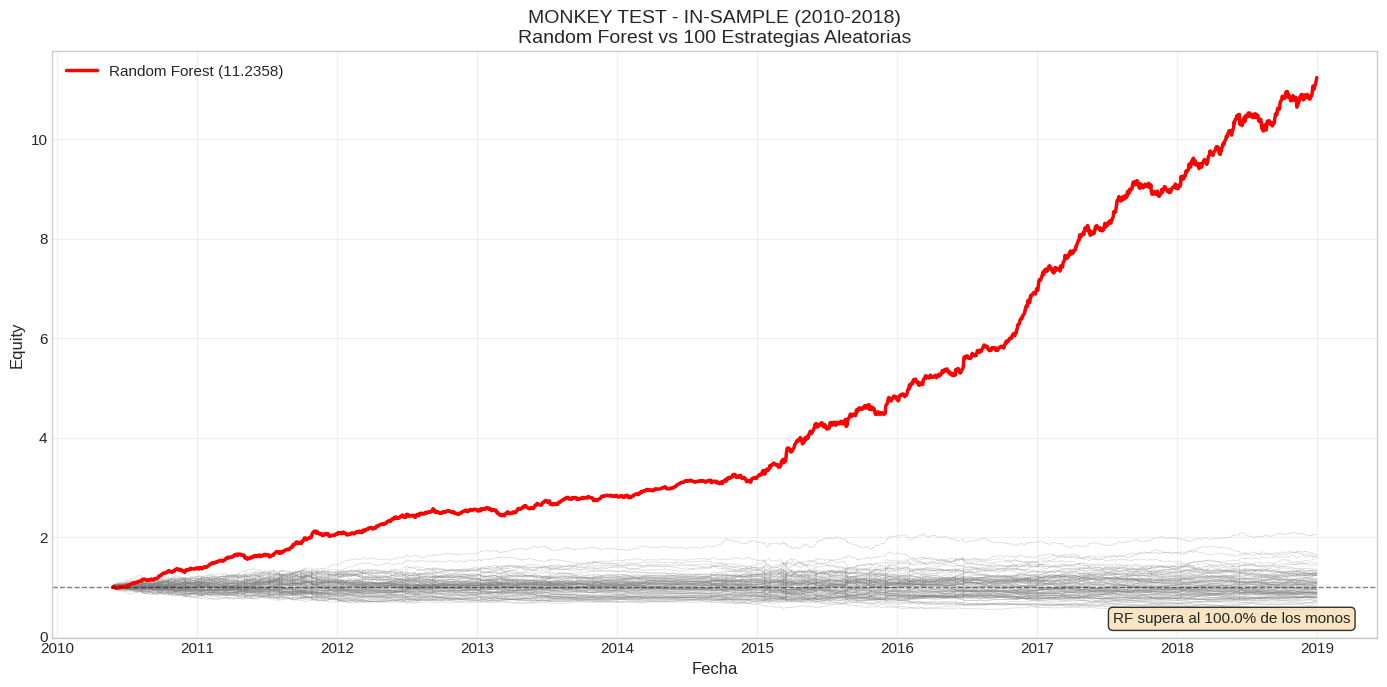


📊 En IN-SAMPLE, el RF supera al 100.0% de los monos


In [ ]:
# ============================================================
# GRÁFICO: MONKEY TEST IN-SAMPLE
# ============================================================

fig, ax = plt.subplots(figsize=(14, 7))

# Dibujar todos los monos (en gris, semitransparente)
for i, eq in enumerate(equities_monos_is):
    ax.plot(df_is.index, eq, color='gray', alpha=0.3, linewidth=0.5)

# Dibujar el Random Forest (en rojo, destacado)
ax.plot(df_is.index, equity_rf_is, color='red', linewidth=2.5, label=f'Random Forest ({equity_rf_is[-1]:.4f})')

# Línea de referencia (equity = 1)
ax.axhline(y=1, color='black', linestyle='--', linewidth=1, alpha=0.5)

# Configuración
ax.set_xlabel('Fecha', fontsize=12)
ax.set_ylabel('Equity', fontsize=12)
ax.set_title(f'MONKEY TEST - IN-SAMPLE (2010-2018)\nRandom Forest vs {N_MONOS} Estrategias Aleatorias', fontsize=14)
ax.legend(loc='upper left', fontsize=11)
ax.grid(True, alpha=0.3)

# Añadir texto con estadísticas
percentil_is = (np.array(equity_final_monos_is) < equity_rf_is[-1]).mean() * 100
textstr = f'RF supera al {percentil_is:.1f}% de los monos'
ax.text(0.98, 0.02, textstr, transform=ax.transAxes, fontsize=11,
        verticalalignment='bottom', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

print(f"\n📊 En IN-SAMPLE, el RF supera al {percentil_is:.1f}% de los monos")

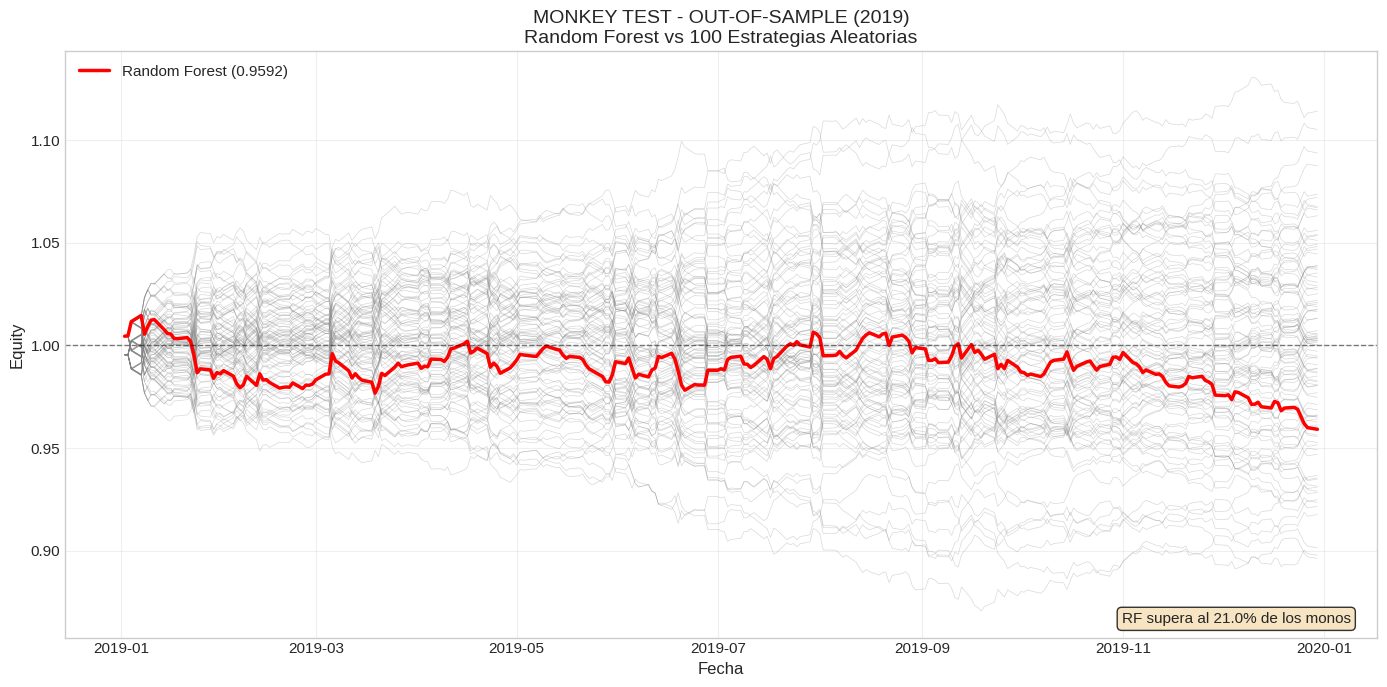


📊 En OUT-OF-SAMPLE, el RF supera al 21.0% de los monos


In [ ]:
# ============================================================
# GRÁFICO: MONKEY TEST OUT-OF-SAMPLE
# ============================================================

fig, ax = plt.subplots(figsize=(14, 7))

# Dibujar todos los monos (en gris, semitransparente)
for i, eq in enumerate(equities_monos_oos):
    ax.plot(df_oos.index, eq, color='gray', alpha=0.3, linewidth=0.5)

# Dibujar el Random Forest (en rojo, destacado)
ax.plot(df_oos.index, equity_rf_oos, color='red', linewidth=2.5, label=f'Random Forest ({equity_rf_oos[-1]:.4f})')

# Línea de referencia (equity = 1)
ax.axhline(y=1, color='black', linestyle='--', linewidth=1, alpha=0.5)

# Configuración
ax.set_xlabel('Fecha', fontsize=12)
ax.set_ylabel('Equity', fontsize=12)
ax.set_title(f'MONKEY TEST - OUT-OF-SAMPLE (2019)\nRandom Forest vs {N_MONOS} Estrategias Aleatorias', fontsize=14)
ax.legend(loc='upper left', fontsize=11)
ax.grid(True, alpha=0.3)

# Añadir texto con estadísticas
percentil_oos = (np.array(equity_final_monos_oos) < equity_rf_oos[-1]).mean() * 100
textstr = f'RF supera al {percentil_oos:.1f}% de los monos'
ax.text(0.98, 0.02, textstr, transform=ax.transAxes, fontsize=11,
        verticalalignment='bottom', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

print(f"\n📊 En OUT-OF-SAMPLE, el RF supera al {percentil_oos:.1f}% de los monos")

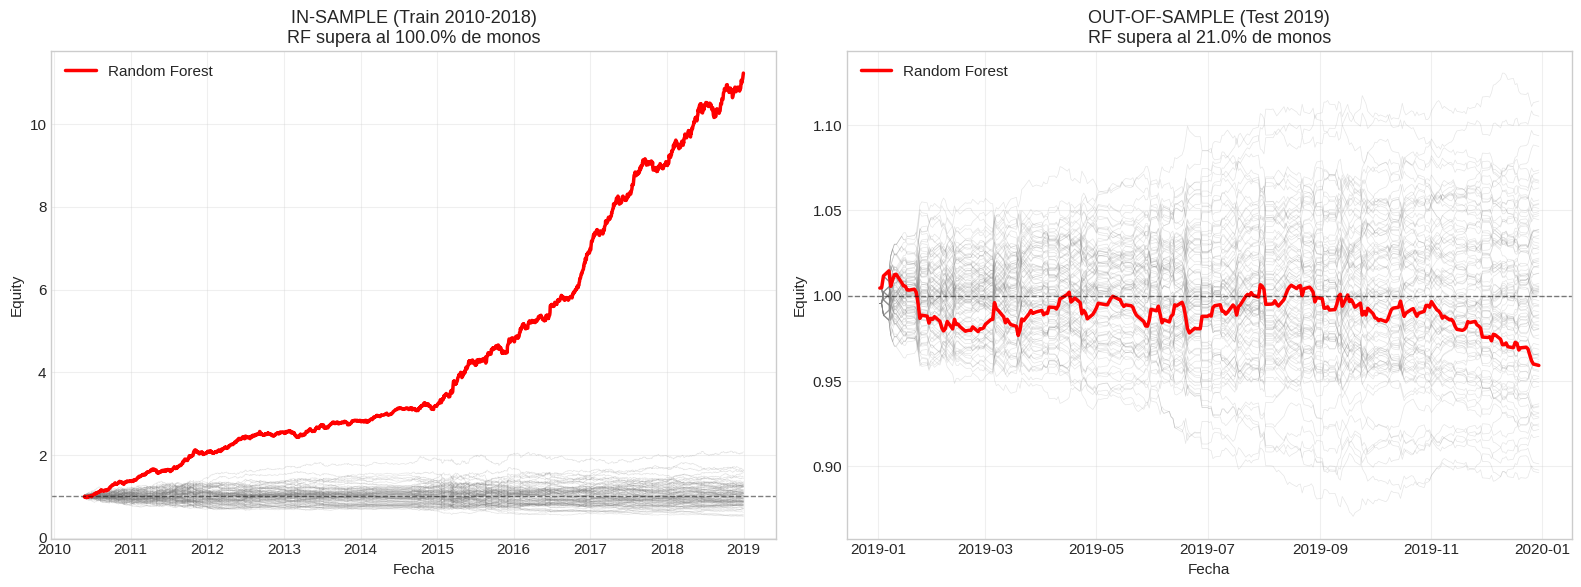

In [ ]:
# ============================================================
# GRÁFICO COMPARATIVO: IS vs OOS
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- IN-SAMPLE ---
ax1 = axes[0]
for eq in equities_monos_is:
    ax1.plot(df_is.index, eq, color='gray', alpha=0.2, linewidth=0.5)
ax1.plot(df_is.index, equity_rf_is, color='red', linewidth=2.5, label='Random Forest')
ax1.axhline(y=1, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax1.set_title(f'IN-SAMPLE (Train 2010-2018)\nRF supera al {percentil_is:.1f}% de monos', fontsize=13)
ax1.set_xlabel('Fecha')
ax1.set_ylabel('Equity')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# --- OUT-OF-SAMPLE ---
ax2 = axes[1]
for eq in equities_monos_oos:
    ax2.plot(df_oos.index, eq, color='gray', alpha=0.2, linewidth=0.5)
ax2.plot(df_oos.index, equity_rf_oos, color='red', linewidth=2.5, label='Random Forest')
ax2.axhline(y=1, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax2.set_title(f'OUT-OF-SAMPLE (Test 2019)\nRF supera al {percentil_oos:.1f}% de monos', fontsize=13)
ax2.set_xlabel('Fecha')
ax2.set_ylabel('Equity')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

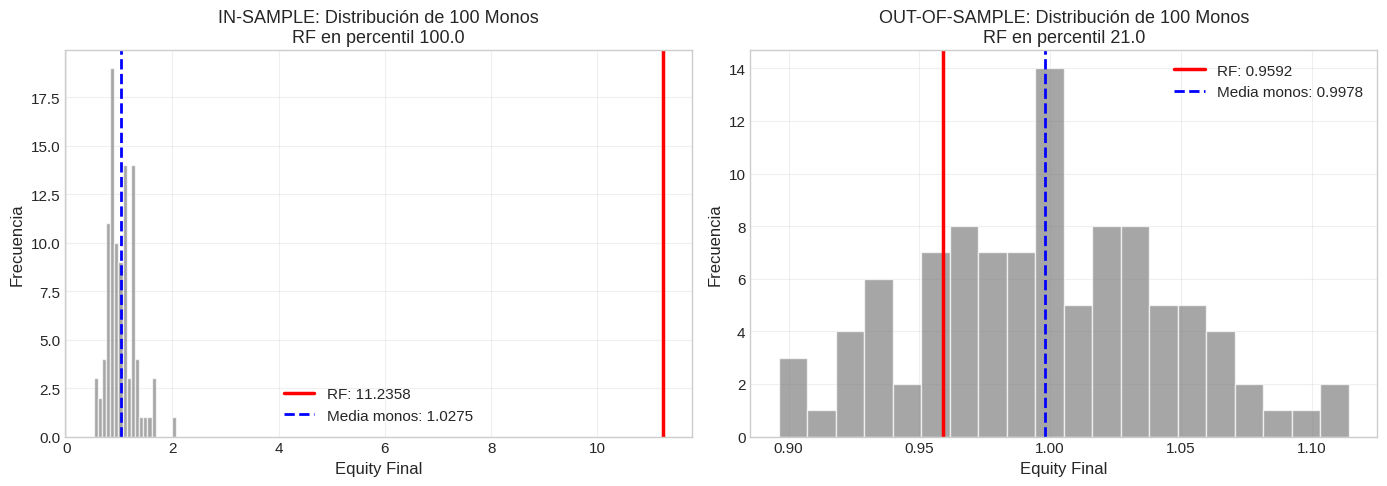

In [ ]:
# ============================================================
# HISTOGRAMA: DISTRIBUCIÓN DE EQUITY FINAL DE LOS MONOS
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- IN-SAMPLE ---
ax1 = axes[0]
ax1.hist(equity_final_monos_is, bins=20, color='gray', alpha=0.7, edgecolor='white')
ax1.axvline(x=equity_rf_is[-1], color='red', linewidth=2.5, linestyle='-', label=f'RF: {equity_rf_is[-1]:.4f}')
ax1.axvline(x=np.mean(equity_final_monos_is), color='blue', linewidth=2, linestyle='--', label=f'Media monos: {np.mean(equity_final_monos_is):.4f}')
ax1.set_xlabel('Equity Final', fontsize=12)
ax1.set_ylabel('Frecuencia', fontsize=12)
ax1.set_title(f'IN-SAMPLE: Distribución de {N_MONOS} Monos\nRF en percentil {percentil_is:.1f}', fontsize=13)
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- OUT-OF-SAMPLE ---
ax2 = axes[1]
ax2.hist(equity_final_monos_oos, bins=20, color='gray', alpha=0.7, edgecolor='white')
ax2.axvline(x=equity_rf_oos[-1], color='red', linewidth=2.5, linestyle='-', label=f'RF: {equity_rf_oos[-1]:.4f}')
ax2.axvline(x=np.mean(equity_final_monos_oos), color='blue', linewidth=2, linestyle='--', label=f'Media monos: {np.mean(equity_final_monos_oos):.4f}')
ax2.set_xlabel('Equity Final', fontsize=12)
ax2.set_ylabel('Frecuencia', fontsize=12)
ax2.set_title(f'OUT-OF-SAMPLE: Distribución de {N_MONOS} Monos\nRF en percentil {percentil_oos:.1f}', fontsize=13)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 11. Interpretación de Resultados

In [ ]:
# ============================================================
# RESUMEN ESTADÍSTICO DEL MONKEY TEST
# ============================================================

print("=" * 70)
print("RESUMEN DEL MONKEY TEST")
print("=" * 70)

print(f"\n{'Métrica':<35} {'IN-SAMPLE':>15} {'OUT-OF-SAMPLE':>15}")
print("-" * 70)

print(f"{'Equity final RF':<35} {equity_rf_is[-1]:>15.4f} {equity_rf_oos[-1]:>15.4f}")
print(f"{'Media monos':<35} {np.mean(equity_final_monos_is):>15.4f} {np.mean(equity_final_monos_oos):>15.4f}")
print(f"{'Mediana monos':<35} {np.median(equity_final_monos_is):>15.4f} {np.median(equity_final_monos_oos):>15.4f}")
print(f"{'Mejor mono':<35} {np.max(equity_final_monos_is):>15.4f} {np.max(equity_final_monos_oos):>15.4f}")
print(f"{'Peor mono':<35} {np.min(equity_final_monos_is):>15.4f} {np.min(equity_final_monos_oos):>15.4f}")
print("-" * 70)
print(f"{'Percentil del RF':<35} {percentil_is:>14.1f}% {percentil_oos:>14.1f}%")
print("=" * 70)

# Interpretación
print("\n📊 INTERPRETACIÓN:")
print("-" * 70)

if percentil_is > 90:
    print(f"   ✅ En IS, el RF está en el percentil {percentil_is:.1f}%")
    print(f"      → Supera claramente a los monos (como esperábamos)")
else:
    print(f"   ⚠️ En IS, el RF está en el percentil {percentil_is:.1f}%")
    print(f"      → No supera significativamente a los monos")

if percentil_oos > 90:
    print(f"\n   ✅ En OOS, el RF está en el percentil {percentil_oos:.1f}%")
    print(f"      → El modelo PODRÍA tener capacidad predictiva real")
elif percentil_oos > 60:
    print(f"\n   ⚠️ En OOS, el RF está en el percentil {percentil_oos:.1f}%")
    print(f"      → Ligeramente mejor que el azar, pero no significativo")
else:
    print(f"\n   ❌ En OOS, el RF está en el percentil {percentil_oos:.1f}%")
    print(f"      → El modelo NO supera a los monos")
    print(f"      → Lo 'aprendido' en IS era probablemente RUIDO")

RESUMEN DEL MONKEY TEST

Métrica                                   IN-SAMPLE   OUT-OF-SAMPLE
----------------------------------------------------------------------
Equity final RF                             11.2358          0.9592
Media monos                                  1.0275          0.9978
Mediana monos                                0.9893          1.0010
Mejor mono                                   2.0773          1.1141
Peor mono                                    0.5155          0.8963
----------------------------------------------------------------------
Percentil del RF                             100.0%           21.0%

📊 INTERPRETACIÓN:
----------------------------------------------------------------------
   ✅ En IS, el RF está en el percentil 100.0%
      → Supera claramente a los monos (como esperábamos)

   ❌ En OOS, el RF está en el percentil 21.0%
      → El modelo NO supera a los monos
      → Lo 'aprendido' en IS era probablemente RUIDO


## 12. ¿Qué Hemos Aprendido?

```
CONCLUSIONES DEL MONKEY TEST
═══════════════════════════════════════════════════════════════════════

    1. EN IN-SAMPLE:
       ─────────────
       El Random Forest supera claramente a los monos.
       
       Pero esto NO significa que el modelo sea bueno.
       Significa que ha "memorizado" patrones en los datos de entrenamiento.
       
       Un modelo siempre puede encontrar patrones en datos pasados,
       incluso si esos patrones son aleatorios.
    
    
    2. EN OUT-OF-SAMPLE:
       ─────────────────
       El Random Forest es "un mono más".
       
       Esto sugiere que los patrones "aprendidos" eran RUIDO,
       no señales reales del mercado.
       
       En datos nuevos, el modelo no tiene ventaja sobre el azar.
    
    
    3. IMPLICACIÓN PARA TRADING:
       ─────────────────────────
       Si tu modelo no supera consistentemente a los monos en OOS,
       NO deberías usarlo para operar con dinero real.
       
       El backtest optimista te engañará.
       El mercado no perdonará.


EL PROBLEMA DE LA SOBREOPTIMIZACIÓN
═══════════════════════════════════════════════════════════════════════

    ¿Qué pasaría si probamos MUCHAS configuraciones del RF
    y nos quedamos con la que mejor funciona en OOS?
    
    → Estaríamos haciendo lo mismo que los monos,
       pero con más sofisticación.
    
    → El "mejor" modelo sería el superviviente de un proceso
       de búsqueda en ruido, no un sistema robusto.
    
    → Necesitamos técnicas para optimizar SIN contaminar el OOS.
```

## 13. Adelanto: Sesión 10 - Optimización

```
¿CÓMO OPTIMIZAR SIN SOBREOPTIMIZAR?
═══════════════════════════════════════════════════════════════════════

    El problema:
    
        Queremos encontrar los mejores hiperparámetros.
        Pero cada vez que "miramos" el OOS para decidir, lo contaminamos.
    
    
    La solución: VALIDACIÓN CRUZADA (Cross-Validation)
    
        En lugar de un único OOS, creamos MÚLTIPLES particiones.
        Cada configuración se evalúa en varios "mini-OOS".
        El OOS final permanece INTOCABLE hasta el último momento.
    
    
    En series temporales: TimeSeriesSplit
    
        Datos:    [═══════════════════════════════════]
        
        Fold 1:   [TRAIN] [val]
        Fold 2:   [TRAIN────] [val]
        Fold 3:   [TRAIN────────] [val]
        Fold 4:   [TRAIN────────────] [val]
        Fold 5:   [TRAIN────────────────] [val]
        
        → Siempre entrenamos con pasado, validamos con futuro
        → Respeta la naturaleza temporal de los datos
    
    
    Herramienta: GridSearchCV
    
        • Define una grilla de hiperparámetros a probar
        • Evalúa cada combinación con Cross-Validation
        • Selecciona la mejor configuración
        • Todo esto SIN tocar el OOS final


PRÓXIMA SESIÓN (10 - Optimización)
═══════════════════════════════════════════════════════════════════════

    Aprenderemos a:
    
    ✓ Usar TimeSeriesSplit para validación cruzada temporal
    ✓ Implementar GridSearchCV para buscar hiperparámetros
    ✓ Evaluar múltiples configuraciones sin contaminar el OOS
    ✓ Obtener estimaciones más robustas del rendimiento real
```

---

## Resumen de la Sesión

En esta sesión hemos aprendido:

✅ **Dos tipos de overfitting:** del modelo y del proceso de desarrollo

✅ **El problema de las múltiples comparaciones:** probar mucho = encontrar ruido

✅ **Data snooping:** usar los mismos datos repetidamente contamina los resultados

✅ **Sesgo de supervivencia:** el "mejor" puede ser solo el más afortunado

✅ **Monkey Test:** comparar tu modelo contra estrategias aleatorias

✅ **La cruda realidad:** un modelo que destaca en IS puede ser un mono más en OOS

### Próxima Sesión

En la **Sesión 10 (8 de febrero)** veremos **Optimización**, donde aprenderemos:

- **GridSearchCV:** Búsqueda sistemática de hiperparámetros
- **TimeSeriesSplit:** Validación cruzada para series temporales
- **Pipeline completo:** Optimizar sin contaminar el OOS final

Esto nos dará herramientas para optimizar de forma **rigurosa y honesta**.